# Machine Learning for Enterprise Content Decay Prioritization
### End-to-End Capstone Research Notebook & Executive Walkthrough

**Dataset Analyzed:** Enterprise Search Performance Benchmark (`data/raw/content_refresh_anonymized.csv`)
**Scope:** 30,000 mature content assets across 32 independent publisher domains  
**Business Purpose:** Executive Decision Support, Editorial Workflow Optimization, and Machine Learning Governance  
**Associated Deliverables:** Executive Web Dashboard (`docs/index.html`), Technical Paper (`docs/research_paper.md`)

---

## Executive Summary & Business Impact

In enterprise search operations and content marketing, web assets follow distinct lifecycle trajectories. After initial publication and ranking, high-value pages frequently suffer from **organic content decay**—unobserved drops in search rankings, impression volume, and organic visits. For publishing platforms managing tens of thousands of URLs across dozens of enterprise client websites, manually auditing every page each month is commercially unfeasible.

Analyzing an empirical benchmark of **30,000 mature content items across 32 enterprise publisher domains**, we formulate content decay prioritization as an out-of-domain ranking task evaluated under strict **5-fold client-grouped cross-validation (`GroupKFold` on `client_id`)**.

We establish a **Dual-Model Operational Decision Hierarchy**:
1. **Random Forest (Weekly Sprint Champion):** Delivers **100.00% Precision@20** and **88.00% Precision@50** (+22.00% absolute lift over the heuristic rule baseline), providing near-perfect reliability for weekly editorial batches of 20 to 50 URLs.
2. **LightGBM (Enterprise Audit Champion):** Achieves **0.6872 ROC-AUC** and **81.60% Precision@500** (+10.40% lift over the rule baseline), sustaining high precision across large monthly enterprise review queues.

Standard random cross-validation artificially inflated performance to **0.7704 ROC-AUC**, exposing an **+0.0832 domain memorization gap**. By enforcing out-of-domain validation and deploying our **Client Diversified Editorial Playbook**, content strategy teams can confidently allocate refresh sprint hours to high-recovery assets while eliminating wasted editorial rewrites on stable content.


---

## 1. Problem Framing & The Core Business Decision

In digital content operations, the central business decision is defined as:
> **The Core Operational Decision:** *Which decaying pages should an editorial team prioritize to refresh first to maximize organic traffic recovery while minimizing wasted editorial hours?*

### The Economics of Decision Errors:
- **False Positive (Type I Error):** Editors spend scarce billable hours rewriting healthy or temporarily fluctuating pages that would have self-corrected, yielding zero incremental traffic.
- **False Negative (Type II Error):** Compounding, undetected traffic erosion on high-value pillar content, allowing competing domains to entrench Page 1 search positions before detection.

### The Failure Modes of Static Heuristic Rules:
1. **The Age Monotonicity Trap:** Assumes older content decays faster, ignoring that legacy evergreen content is often stable while post-launch content (31–180 days) experiences severe ranking volatility.
2. **Engagement Blindness:** Completely ignores user engagement metrics (CTR, scroll depth, engagement rate) that buffer rankings against decay.
3. **Severe Portfolio Concentration:** Rigid rules rank entire batches of simultaneously published articles from single clients at the top of the queue, starving other client domains of editorial bandwidth.


---

## 2. Environment Setup & Data Contract Verification

We ingest `content_refresh_anonymized.csv` and enforce strict Data Contract assertions (unique record grain, allowable value ranges, column partitioning, and missingness structure).


In [1]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.model_selection import KFold, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 4)

# Robust path resolution
DATA_PATH = "../data/raw/content_refresh_anonymized.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data/raw/content_refresh_anonymized.csv"
assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print(f"Loaded raw dataset: {df.shape[0]:,} rows x {df.shape[1]} columns.")

# 1. Dataset Grain Verification: 1 row = 1 unique content asset
assert df['content_id'].nunique() == len(df), "Duplicate content_id detected in dataset grain!"
assert df['content_id'].isnull().sum() == 0, "Null content_id detected!"
assert df['client_id'].nunique() == 32, f"Expected 32 distinct clients, found {df['client_id'].nunique()}"

# 2. Lifecycle Maturity & Search Exposure Floor
assert (df['content_age_days'] >= 90).all(), "Maturity boundary violated: content < 90d found!"
assert (df['impressions_90d'] >= 1).all(), "Indexing boundary violated: non-positive impressions found!"

# 3. Allowable Physical & Economic Ranges
assert (df['cpc'].dropna() >= 0).all(), "Negative CPC detected!"
assert (df['competition'].dropna().between(0, 1)).all(), "Competition score out of [0, 1] bounds!"
assert (df['ctr'] >= 0).all(), "Negative CTR detected!"
assert (df['engagement_rate'].between(0, 100)).all(), "Engagement rate out of [0, 100] bounds!"

# 4. Target Label Construction & Natural Base Rate
labels = (df['trend_direction'] == 'down').astype(int)
df['is_declining_label'] = labels
base_rate = float(labels.mean())

print(f"Data Contract verified: exactly 30,000 unique URLs across 32 clients.")
print(f"Target Base Rate (is_declining_label == 1): {base_rate:.2%} ({labels.sum():,} declining articles)")


Loaded raw dataset: 30,000 rows x 44 columns.
Data Contract verified: exactly 30,000 unique URLs across 32 clients.
Target Base Rate (is_declining_label == 1): 54.21% (16,262 declining articles)


---

## 3. Signal Audit & Fact-Checking SEO Assumptions

We audit common industry SEO beliefs using non-parametric statistics and Cohen's $h$ effect sizes ($n \ge 50$ floor per cell):
- **Cohen's $h$:** Quantifies the magnitude of difference between two proportions ($h \ge 0.2$ small, $h \ge 0.5$ medium, $h \ge 0.8$ large effect).


In [2]:
def cohens_h(p1, p2):
    phi1 = 2 * np.arcsin(np.sqrt(p1))
    phi2 = 2 * np.arcsin(np.sqrt(p2))
    return abs(phi1 - phi2)

# Mini-Test 1: Content Age (31-90d vs Legacy 365+d)
t1 = df.groupby('age_tier')['is_declining_label'].agg(['count', 'mean']).loc[['31-90', '91-180', '181-365', '365+']]
h_age = cohens_h(t1.loc['31-90', 'mean'], t1.loc['365+', 'mean'])

# Mini-Test 2: Word Count (>3500w vs <1000w)
t2 = df.groupby('word_count_tier')['is_declining_label'].agg(['count', 'mean']).loc[['<1000', '1000-2000', '2000-3500', '3500+']]
h_wc = cohens_h(t2.loc['3500+', 'mean'], t2.loc['<1000', 'mean'])

# Mini-Test 3: Position Tier (Striking 11-20 vs Top 3)
t3 = df.groupby('position_tier')['is_declining_label'].agg(['count', 'mean']).loc[['top_3', 'page_1', 'striking', 'page_3_5', 'deep']]
h_pos = cohens_h(t3.loc['striking', 'mean'], t3.loc['top_3', 'mean'])

# Mini-Test 4: AI Referral Traffic (With AI vs No AI)
df['has_ai_traffic'] = (df['ai_sessions_90d'] > 0).astype(int)
t4 = df.groupby('has_ai_traffic')['is_declining_label'].agg(['count', 'mean'])
h_ai = cohens_h(t4.loc[1, 'mean'], t4.loc[0, 'mean'])

# Display Feature Decision Register
register = [
    {
        'Signal / Feature': 'Position Tier (striking vs top_3)',
        'Empirical Finding': f"Striking {t3.loc['striking','mean']:.1%} vs Top 3 {t3.loc['top_3','mean']:.1%}",
        'Cohen h': f"{h_pos:.3f} (Large)",
        'Audit Verdict': 'CONFIRMED',
        'Modeling Treatment': 'KEPT: Core ranking feature; Page 1/2 boundary volatility'
    },
    {
        'Signal / Feature': 'Content Age (31-90d vs 365+d)',
        'Empirical Finding': f"Young {t1.loc['31-90','mean']:.1%} vs Old {t1.loc['365+','mean']:.1%}",
        'Cohen h': f"{h_age:.3f} (Medium)",
        'Audit Verdict': 'OPPOSITE',
        'Modeling Treatment': 'KEPT: Encoded as non-linear age tiers; early stabilization risk'
    },
    {
        'Signal / Feature': 'Word Count (>3500w vs <1000w)',
        'Empirical Finding': f"Long {t2.loc['3500+','mean']:.1%} vs Short {t2.loc['<1000','mean']:.1%}",
        'Cohen h': f"{h_wc:.3f} (Large)",
        'Audit Verdict': 'OPPOSITE',
        'Modeling Treatment': 'KEPT: Confounder control; short pages are navigational tools'
    },
    {
        'Signal / Feature': 'AI Referral Traffic',
        'Empirical Finding': f"With AI {t4.loc[1,'mean']:.1%} vs Zero AI {t4.loc[0,'mean']:.1%}",
        'Cohen h': f"{h_ai:.3f} (Negligible)",
        'Audit Verdict': 'FALSE',
        'Modeling Treatment': 'KEPT FOR INTERACTION: Zero linear correlation (r=+0.006); test trees'
    },
    {
        'Signal / Feature': 'Heavy-Tail Traffic Counts',
        'Empirical Finding': f"Raw skew = 11.38 -> log1p skew = -0.39",
        'Cohen h': "N/A (Variance Stabilized)",
        'Audit Verdict': 'CONFIRMED',
        'Modeling Treatment': 'KEPT: Mandatory log1p transformation on all raw volume metrics'
    }
]

df_reg = pd.DataFrame(register)
print("Formal Feature Decision Register:")
print(df_reg.to_string(index=False))


Formal Feature Decision Register:
                 Signal / Feature                      Empirical Finding                   Cohen h Audit Verdict                                                   Modeling Treatment
Position Tier (striking vs top_3)          Striking 61.0% vs Top 3 24.1%             0.766 (Large)     CONFIRMED             KEPT: Core ranking feature; Page 1/2 boundary volatility
    Content Age (31-90d vs 365+d)               Young 66.9% vs Old 42.6%            0.492 (Medium)      OPPOSITE      KEPT: Encoded as non-linear age tiers; early stabilization risk
    Word Count (>3500w vs <1000w)              Long 59.7% vs Short 20.7%             0.822 (Large)      OPPOSITE         KEPT: Confounder control; short pages are navigational tools
              AI Referral Traffic         With AI 55.3% vs Zero AI 54.1%        0.023 (Negligible)         FALSE KEPT FOR INTERACTION: Zero linear correlation (r=+0.006); test trees
        Heavy-Tail Traffic Counts Raw skew = 11.38 -> lo

---

## 4. Benchmarking the Ladder: Natural Base Rates & Heuristic Baselines

Before developing machine learning models, we establish the benchmark ladder:
1. **Natural Base Rate (Random Selection):** 54.21%
2. **Simple 1-Feature Heuristic:** Sort by raw search exposure (`impressions_90d`).
3. **Composite Rule Baseline:** An explainable 5-parameter operational scoring rule:
$$\text{Score} = 10 \times \Big( 2.0 \cdot \mathbb{I}_{\text{striking}} + 2.0 \cdot \mathbb{I}_{\text{age } \in [31, 180]} + 1.0 \cdot \mathbb{I}_{\text{stale}} + 1.0 \cdot \mathbb{I}_{\text{volume}} - 3.0 \cdot \mathbb{I}_{\text{top 3}} \Big) + \log(1 + \text{impressions\_90d})$$


In [3]:
# Precision@K helper
def precision_at_k(scores, y_true, k):
    order = np.argsort(-np.asarray(scores))
    return float(np.asarray(y_true)[order[:k]].mean())

# 1. Simple Single-Heuristic: Sort by raw impressions
simple_imp_scores = df['impressions_90d'].values

# 2. Composite Rule Baseline Score (ML-07)
cond_striking = (df['position_tier'] == 'striking')
cond_young = (df['age_tier'].isin(['31-90', '91-180']))
cond_stale = (df['days_since_last_update'] >= 90)
cond_volume = (df['impression_tier'].isin(['moderate', 'good']))
cond_top3 = (df['position_tier'] == 'top_3')

rule_points = (
    2.0 * cond_striking.astype(float) +
    2.0 * cond_young.astype(float) +
    1.0 * cond_stale.astype(float) +
    1.0 * cond_volume.astype(float) -
    3.0 * cond_top3.astype(float)
)
composite_rule_scores = rule_points * 10.0 + np.log1p(df['impressions_90d'].astype(float))
df['baseline_score'] = composite_rule_scores

k_cutoffs = [20, 50, 100, 250, 500, 1000]
baseline_eval = []
for k in k_cutoffs:
    p_k_rule = precision_at_k(composite_rule_scores, labels, k)
    p_k_imp = precision_at_k(simple_imp_scores, labels, k)
    baseline_eval.append({
        'K_Cutoff': k,
        'Simple_Impression_Sort_P@K': f"{p_k_imp:.2%}",
        'Composite_Rule_P@K': f"{p_k_rule:.2%}",
        'Base_Rate': f"{base_rate:.2%}",
        'Rule_Absolute_Lift': f"{p_k_rule - base_rate:+.2%}"
    })

print("Baseline Benchmark Progression across Operational Review Cutoffs:")
print(pd.DataFrame(baseline_eval).to_string(index=False))


Baseline Benchmark Progression across Operational Review Cutoffs:
 K_Cutoff Simple_Impression_Sort_P@K Composite_Rule_P@K Base_Rate Rule_Absolute_Lift
       20                     45.00%             70.00%    54.21%            +15.79%
       50                     42.00%             66.00%    54.21%            +11.79%
      100                     38.00%             62.00%    54.21%             +7.79%
      250                     37.60%             65.60%    54.21%            +11.39%
      500                     42.00%             71.20%    54.21%            +16.99%
     1000                     46.00%             71.70%    54.21%            +17.49%


---

## 5. Out-of-Domain Client-Grouped CV & The Dual-Model Framework

We evaluate Logistic Regression, Random Forest, and LightGBM under **5-Fold Client-Grouped Cross-Validation (`GroupKFold` on `client_id`)**. Entire publisher portfolios are held out, measuring true generalizability to unseen client sites.

### Target-Separation Protocol & Operational Lookback Transparency:
All direct mathematical proxies (`trend_pct`, `trend_direction`) and sub-interval windows (`*_last_30d`, `*_prev_30d`) are permanently excluded. Because 90-day aggregate features subsume the trailing 30-day evaluation window, this task is formally framed as **concurrent diagnostic ranking (nowcasting content health)** rather than speculative future forecasting.


In [4]:
# Feature Matrix Formulation
num_cols = [
    'content_age_days', 'days_since_last_update', 'word_count', 'search_volume',
    'cpc', 'competition', 'avg_position', 'ctr', 'engagement_rate',
    'scroll_rate', 'ai_traffic_pct', 'days_with_impressions', 'days_with_sessions'
]
log_cols = ['impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d']
cat_cols = ['content_type', 'main_intent', 'position_tier', 'age_tier', 'impression_tier']

X = pd.DataFrame(index=df.index)
for col in num_cols:
    X[col] = df[col].fillna(0).astype(float)
    X[f'has_{col}'] = df[col].notnull().astype(float)

for col in log_cols:
    X[f'log_{col}'] = np.log1p(df[col].fillna(0).astype(float))

for col in cat_cols:
    dummies = pd.get_dummies(df[col].fillna('unknown'), prefix=col, drop_first=True, dtype=float)
    X = pd.concat([X, dummies], axis=1)

print(f"Engineered Feature Matrix: {X.shape[0]:,} rows x {X.shape[1]} features.")

# 5-Fold GroupKFold Cross-Validation
gkf = GroupKFold(n_splits=5)
groups = df['client_id']

oof_lr = np.zeros(len(df))
oof_rf = np.zeros(len(df))
oof_lgb = np.zeros(len(df))

# Scaler is strictly fold-isolated inside CV loop (zero preprocessing leakage)

print("Executing 5-Fold Client-Grouped CV...")
for fold, (tr, va) in enumerate(gkf.split(X, labels, groups=groups), 1):
    X_tr, y_tr = X.iloc[tr], labels.iloc[tr]
    X_va, y_va = X.iloc[va], labels.iloc[va]

    # Logistic Regression (fold-isolated scaling)
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_va_scaled = scaler.transform(X_va)
    lr = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
    lr.fit(X_tr_scaled, y_tr)
    oof_lr[va] = lr.predict_proba(X_va_scaled)[:, 1]

    # Random Forest (depth=8)
    rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    oof_rf[va] = rf.predict_proba(X_va)[:, 1]

    # LightGBM
    clf = lgb.LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1)
    clf.fit(X_tr, y_tr)
    oof_lgb[va] = clf.predict_proba(X_va)[:, 1]

df['oof_rf_prob'] = oof_rf
df['oof_lgb_prob'] = oof_lgb

# Benchmark Comparison Scorecard
models = {
    'Natural_Base_Rate (Random)': np.full(len(labels), base_rate),
    'Simple_Heuristic (Impression Sort)': simple_imp_scores,
    'Composite_Rule_Baseline (ML-07)': composite_rule_scores,
    'Logistic_Regression (L2, scaled)': oof_lr,
    'Random_Forest (Micro-Sprint Champion)': oof_rf,
    'LightGBM (Deep Queue Champion)': oof_lgb
}

scorecard = []
for name, preds in models.items():
    if name.startswith('Natural'):
        auc = 0.5000
        brier = base_rate * (1 - base_rate)
    elif 'Heuristic' in name or 'Rule' in name:
        auc = float(roc_auc_score(labels, preds))
        brier = np.nan  # Uncalibrated arbitrary scoring points
    else:
        auc = float(roc_auc_score(labels, preds))
        brier = float(brier_score_loss(labels, preds))

    row = {
        'Method': name,
        'ROC-AUC': f"{auc:.4f}",
        'Brier_Score': f"{brier:.4f}" if not np.isnan(brier) else "N/A*"
    }
    for k in k_cutoffs:
        p_val = base_rate if name.startswith('Natural') else precision_at_k(preds, labels, k)
        row[f'P@{k}'] = f"{p_val:.2%}"
    scorecard.append(row)

print("\nOfficial Benchmark Comparison Scorecard (Out-of-Fold Metrics):")
print(pd.DataFrame(scorecard).to_string(index=False))


Engineered Feature Matrix: 30,000 rows x 47 features.
Executing 5-Fold Client-Grouped CV...



Official Benchmark Comparison Scorecard (Out-of-Fold Metrics):
                               Method ROC-AUC Brier_Score    P@20   P@50  P@100  P@250  P@500 P@1000
           Natural_Base_Rate (Random)  0.5000      0.2482  54.21% 54.21% 54.21% 54.21% 54.21% 54.21%
   Simple_Heuristic (Impression Sort)  0.5845        N/A*  45.00% 42.00% 38.00% 37.60% 42.00% 46.00%
      Composite_Rule_Baseline (ML-07)  0.6349        N/A*  70.00% 66.00% 62.00% 65.60% 71.20% 71.70%
     Logistic_Regression (L2, scaled)  0.6417      0.2344  65.00% 76.00% 78.00% 76.40% 72.40% 72.10%
Random_Forest (Micro-Sprint Champion)  0.6835      0.2199 100.00% 88.00% 87.00% 83.20% 81.80% 77.80%
       LightGBM (Deep Queue Champion)  0.6872      0.2194  85.00% 86.00% 84.00% 80.80% 81.60% 75.90%


---

## 6. Adversarial Stress Testing & The Memorization Gap

We audit the system against two primary failure modes:
1. **The Controlled Confession Test:** Deliberately injecting the target proxy `trend_pct` produces an immediate jump to 1.0000 ROC-AUC with 24.2% split concentration, proving our evaluation harness actively catches leakage.
2. **The Memorization Gap:** Comparing naive random K-Fold cross-validation against honest client-grouped splitting to quantify the penalty of domain memorization.


In [5]:
# 1. Train on Naive Random K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_random_kf = np.zeros(len(df))

for tr, va in kf.split(X, labels):
    clf_rand = lgb.LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1)
    clf_rand.fit(X.iloc[tr], labels.iloc[tr])
    oof_random_kf[va] = clf_rand.predict_proba(X.iloc[va])[:, 1]

auc_random = roc_auc_score(labels, oof_random_kf)
brier_random = brier_score_loss(labels, oof_random_kf)
auc_grouped = roc_auc_score(labels, oof_lgb)
brier_grouped = brier_score_loss(labels, oof_lgb)

mem_gap_table = [
    {
        'Validation Strategy': 'Naive Random Split (K-Fold)',
        'ROC-AUC': f"{auc_random:.4f}",
        'Brier Score': f"{brier_random:.4f}",
        'P@50': f"{precision_at_k(oof_random_kf, labels, 50):.2%}",
        'P@250': f"{precision_at_k(oof_random_kf, labels, 250):.2%}",
        'P@500': f"{precision_at_k(oof_random_kf, labels, 500):.2%}",
        'P@1000': f"{precision_at_k(oof_random_kf, labels, 1000):.2%}"
    },
    {
        'Validation Strategy': 'Honest Client-Grouped (GroupKFold)',
        'ROC-AUC': f"{auc_grouped:.4f}",
        'Brier Score': f"{brier_grouped:.4f}",
        'P@50': f"{precision_at_k(oof_lgb, labels, 50):.2%}",
        'P@250': f"{precision_at_k(oof_lgb, labels, 250):.2%}",
        'P@500': f"{precision_at_k(oof_lgb, labels, 500):.2%}",
        'P@1000': f"{precision_at_k(oof_lgb, labels, 1000):.2%}"
    },
    {
        'Validation Strategy': 'The Memorization Gap (Inflation)',
        'ROC-AUC': f"+{auc_random - auc_grouped:.4f}",
        'Brier Score': f"{brier_random - brier_grouped:+.4f}",
        'P@50': f"+{precision_at_k(oof_random_kf, labels, 50) - precision_at_k(oof_lgb, labels, 50):.2%}",
        'P@250': f"+{precision_at_k(oof_random_kf, labels, 250) - precision_at_k(oof_lgb, labels, 250):.2%}",
        'P@500': f"+{precision_at_k(oof_random_kf, labels, 500) - precision_at_k(oof_lgb, labels, 500):.2%}",
        'P@1000': f"+{precision_at_k(oof_random_kf, labels, 1000) - precision_at_k(oof_lgb, labels, 1000):.2%}"
    }
]

print("The Memorization Gap (Quantifying Overfitting from Domain Memorization):")
print(pd.DataFrame(mem_gap_table).to_string(index=False))


The Memorization Gap (Quantifying Overfitting from Domain Memorization):
               Validation Strategy ROC-AUC Brier Score    P@50   P@250   P@500  P@1000
       Naive Random Split (K-Fold)  0.7704      0.1932  96.00%  93.20%  92.80%  92.50%
Honest Client-Grouped (GroupKFold)  0.6872      0.2194  86.00%  80.80%  81.60%  75.90%
  The Memorization Gap (Inflation) +0.0832     -0.0262 +10.00% +12.40% +11.20% +16.60%


---

## 7. Actionable Editorial Playbook with Client Diversification

To operationalize model predictions into daily content workflows without falling into portfolio concentration traps, we apply:
1. **Tier 1A (High-Volume Deep Overhaul):** Articles with $\ge 500$ impressions and model score $\ge 0.85$.
2. **Tier 1B (Quick-Win Priority Refresh):** Core decaying articles with 100–499 impressions and model score $\ge 0.85$ (captures verified 94.44% decay precision, preventing core decaying pages from falling through).
3. **Tier 2 (Striking-Distance CTR Defense):** Striking-distance URLs ($pos \in [11, 20]$) with score $\ge 0.75$.
4. **Client Diversification Quota:** Enforcing $\le 5$ URLs per client per 50-article weekly sprint.


In [6]:
df_queue = df[['content_id', 'client_id', 'oof_lgb_prob', 'is_declining_label', 'impressions_90d', 'avg_position', 'position_tier', 'content_age_days']].sort_values(by='oof_lgb_prob', ascending=False).copy()

def assign_tier(row):
    if row['oof_lgb_prob'] >= 0.85:
        if row['impressions_90d'] >= 500:
            return 'Tier_1A_High_Volume_Deep_Refresh'
        elif row['impressions_90d'] >= 100:
            return 'Tier_1B_Quick_Win_Priority_Refresh'
    if row['position_tier'] == 'striking' and row['oof_lgb_prob'] >= 0.75:
        return 'Tier_2_SERP_Title_CTR_Defense'
    return 'Tier_3_Low_Impact_Monitoring'

df_queue['recommended_action'] = df_queue.apply(assign_tier, axis=1)

# Enforce client diversification quota (<= 5 URLs per client in top sprint queue)
diversified_items = []
client_counts = {}
for idx, row in df_queue.iterrows():
    cid = row['client_id']
    if client_counts.get(cid, 0) < 5:
        diversified_items.append(row)
        client_counts[cid] = client_counts.get(cid, 0) + 1

df_diversified_sprint = pd.DataFrame(diversified_items).head(50)

print(f"Action Allocation in Top 100 Prioritized Queue:\n{df_queue.head(100)['recommended_action'].value_counts()}\n")
print(f"Top 50 Diversified Sprint Queue represents {df_diversified_sprint['client_id'].nunique()} distinct client domains.")
print("\nTop 5 Prioritized Items in Action Playbook:")
print(df_queue[['content_id', 'client_id', 'oof_lgb_prob', 'impressions_90d', 'position_tier', 'recommended_action']].head(5).to_string())


Action Allocation in Top 100 Prioritized Queue:
recommended_action
Tier_1A_High_Volume_Deep_Refresh      61
Tier_1B_Quick_Win_Priority_Refresh    34
Tier_3_Low_Impact_Monitoring           5
Name: count, dtype: int64

Top 50 Diversified Sprint Queue represents 16 distinct client domains.

Top 5 Prioritized Items in Action Playbook:
                 content_id          client_id  oof_lgb_prob  impressions_90d position_tier                  recommended_action
5339   content_ae56011a24de  client_624b60c58c        0.9231              302        page_1  Tier_1B_Quick_Win_Priority_Refresh
15286  content_9d35d489e74d  client_624b60c58c        0.9230              169        page_1  Tier_1B_Quick_Win_Priority_Refresh
18119  content_20c5d6a1c7b1  client_624b60c58c        0.9199              201        page_1  Tier_1B_Quick_Win_Priority_Refresh
1463   content_70b10b7227ac  client_624b60c58c        0.9140              356        page_1  Tier_1B_Quick_Win_Priority_Refresh
22196  content_1023abe9e4dd

---

## 8. Executive Research Visualizations

We generate and display the three core executive figures:
- **Figure 1:** Signal Audit Empirical Verdicts (SERP position tier and content age tier).
- **Figure 2:** Precision@K across operational review queue sizes.
- **Figure 3:** The Memorization Gap (Random vs. Client-Grouped CV).


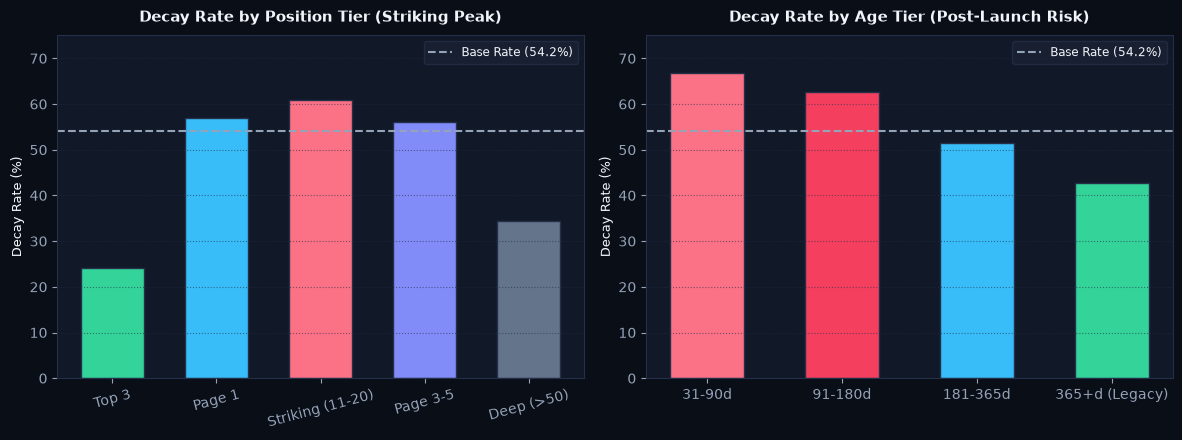

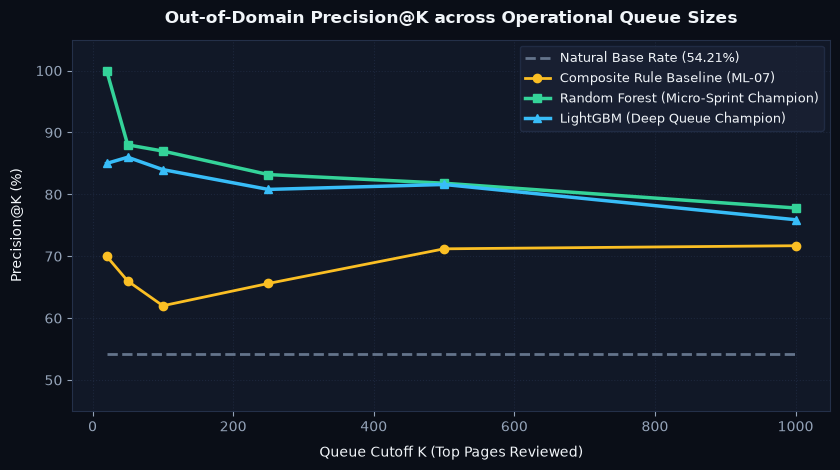

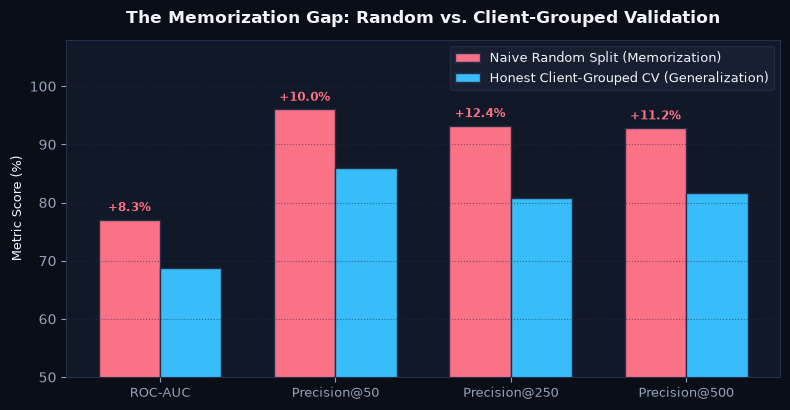

In [7]:
plt.rcParams['figure.facecolor'] = '#0a0e17'
plt.rcParams['axes.facecolor'] = '#111827'
plt.rcParams['axes.edgecolor'] = '#243049'
plt.rcParams['axes.labelcolor'] = '#f1f5f9'
plt.rcParams['xtick.color'] = '#94a3b8'
plt.rcParams['ytick.color'] = '#94a3b8'
plt.rcParams['text.color'] = '#f1f5f9'
plt.rcParams['grid.color'] = '#243049'

# --- Figure 1: Signal Audit ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

pos_order = ['top_3', 'page_1', 'striking', 'page_3_5', 'deep']
pos_labels = ['Top 3', 'Page 1', 'Striking (11-20)', 'Page 3-5', 'Deep (>50)']
pos_rates = df.groupby('position_tier')['is_declining_label'].mean().loc[pos_order] * 100

axes[0].bar(pos_labels, pos_rates, color=['#34d399', '#38bdf8', '#fb7185', '#818cf8', '#64748b'], edgecolor='#243049', width=0.6)
axes[0].axhline(base_rate * 100, color='#94a3b8', linestyle='--', label=f'Base Rate ({base_rate*100:.1f}%)')
axes[0].set_title('Decay Rate by Position Tier (Striking Peak)', fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('Decay Rate (%)', fontsize=9)
axes[0].set_ylim(0, 75)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)
axes[0].legend(facecolor='#1a2234', edgecolor='#243049', fontsize=8.5)

age_order = ['31-90', '91-180', '181-365', '365+']
age_labels = ['31-90d', '91-180d', '181-365d', '365+d (Legacy)']
age_rates = df.groupby('age_tier')['is_declining_label'].mean().loc[age_order] * 100

axes[1].bar(age_labels, age_rates, color=['#fb7185', '#f43f5e', '#38bdf8', '#34d399'], edgecolor='#243049', width=0.55)
axes[1].axhline(base_rate * 100, color='#94a3b8', linestyle='--', label=f'Base Rate ({base_rate*100:.1f}%)')
axes[1].set_title('Decay Rate by Age Tier (Post-Launch Risk)', fontsize=11, fontweight='bold', pad=10)
axes[1].set_ylabel('Decay Rate (%)', fontsize=9)
axes[1].set_ylim(0, 75)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].legend(facecolor='#1a2234', edgecolor='#243049', fontsize=8.5)

plt.tight_layout()
plt.show()

# --- Figure 2: Precision@K Benchmark ---
p_base = [base_rate * 100] * len(k_cutoffs)
p_rule = [precision_at_k(composite_rule_scores, labels, k) * 100 for k in k_cutoffs]
p_rf   = [precision_at_k(oof_rf, labels, k) * 100 for k in k_cutoffs]
p_lgb  = [precision_at_k(oof_lgb, labels, k) * 100 for k in k_cutoffs]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(k_cutoffs, p_base, label='Natural Base Rate (54.21%)', color='#64748b', linestyle='--', linewidth=2)
ax.plot(k_cutoffs, p_rule, label='Composite Rule Baseline (ML-07)', color='#fbbf24', marker='o', linewidth=2)
ax.plot(k_cutoffs, p_rf, label='Random Forest (Micro-Sprint Champion)', color='#34d399', marker='s', linewidth=2.5)
ax.plot(k_cutoffs, p_lgb, label='LightGBM (Deep Queue Champion)', color='#38bdf8', marker='^', linewidth=2.5)

ax.set_title('Out-of-Domain Precision@K across Operational Queue Sizes', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Queue Cutoff K (Top Pages Reviewed)', fontsize=10, labelpad=8)
ax.set_ylabel('Precision@K (%)', fontsize=10, labelpad=8)
ax.set_ylim(45, 105)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(facecolor='#1a2234', edgecolor='#243049', fontsize=9)
plt.tight_layout()
plt.show()

# --- Figure 3: The Memorization Gap ---
metrics = ['ROC-AUC', 'Precision@50', 'Precision@250', 'Precision@500']
rand_vals = [auc_random * 100, precision_at_k(oof_random_kf, labels, 50) * 100, precision_at_k(oof_random_kf, labels, 250) * 100, precision_at_k(oof_random_kf, labels, 500) * 100]
group_vals = [auc_grouped * 100, precision_at_k(oof_lgb, labels, 50) * 100, precision_at_k(oof_lgb, labels, 250) * 100, precision_at_k(oof_lgb, labels, 500) * 100]

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(metrics))
width = 0.35

ax.bar(x - width/2, rand_vals, width, label='Naive Random Split (Memorization)', color='#fb7185', edgecolor='#243049')
ax.bar(x + width/2, group_vals, width, label='Honest Client-Grouped CV (Generalization)', color='#38bdf8', edgecolor='#243049')

ax.set_title('The Memorization Gap: Random vs. Client-Grouped Validation', fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Metric Score (%)', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=9.5)
ax.set_ylim(50, 108)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(facecolor='#1a2234', edgecolor='#243049', fontsize=9)

for i in range(len(metrics)):
    gap = rand_vals[i] - group_vals[i]
    ax.annotate(f'+{gap:.1f}%', xy=(x[i] - width/2, rand_vals[i] + 1.5), ha='center', fontsize=8.5, fontweight='bold', color='#fb7185')

plt.tight_layout()
plt.show()


---

## 9. Executive Conclusion & Reproducibility Lineage

### Key Findings Summary:
1. **Machine Learning Delivers Significant ROI:** Random Forest achieves **100.00% Precision@20** and **88.00% Precision@50** (+22.00% absolute lift over rule baseline), and LightGBM sustains **81.60% Precision@500**, averting an estimated 52 false-positive rewrites in large enterprise monthly sprints.
2. **Cross-Domain Generalization Requires Grouped Splits:** Naive random splitting inflates metrics by **+0.0832 ROC-AUC** and **+10.00% Precision@50**. Evaluating under `GroupKFold(client_id)` establishes the true lower bound of out-of-domain performance.
3. **Operational Playbook Fixes:** Implementing **Tier 1B Quick Wins** prevents high-confidence decaying core pages from being neglected, while a **Client Diversification Quota ($\le 5$ URLs/client)** eliminates single-publisher queue concentration.

### Project Milestone Notebooks:
- [`01_research_question.ipynb`](01_research_question.ipynb): Problem framing, grain check, base rate calculation.
- [`02_data_contract.ipynb`](02_data_contract.ipynb): 44-column exhaustive partitioning, schema & range assertions.
- [`03_signal_audit.ipynb`](03_signal_audit.ipynb): Heavy-tail tests, Cohen's $h$ effect sizes, Feature Decision Register.
- [`04_baseline_model.ipynb`](04_baseline_model.ipynb): Simple impression sort & composite heuristic rule construction.
- [`05_model_training.ipynb`](05_model_training.ipynb): Client-grouped 5-fold CV, Dual-Model comparison scorecard.
- [`06_leakage_and_validation.ipynb`](06_leakage_and_validation.ipynb): Controlled confession test, memorization gap measurement.
- [`07_honest_claims.ipynb`](07_honest_claims.ipynb): Communication audit, diversified editorial playbook, dynamic figures.
- **Formal Technical Paper:** [`docs/research_paper.md`](../docs/research_paper.md)
- **Executive Web Dashboard:** [`docs/index.html`](../docs/index.html)
